# Geo Incrementality Experiment: Did the Campaign Drive Real Sales?

This notebook measures the incremental sales impact of a geo-targeted marketing campaign using a **matched-market design** analyzed with **CausalImpact**.

The data is Google's public [matched_markets](https://github.com/google/matched_markets) example dataset: daily sales for 100 geos (Jan 5 – Apr 7, 2015), with a designed geo experiment — 50 treatment geos received **$50,000** of ad spend between **Feb 16 and Mar 15, 2015**, while 50 control geos received none. Because the spend data is real, the incremental ROAS estimate at the end is grounded in actual campaign cost, not an assumption.

---
# Phase 1: Framing & Experiment Design

## The Core Challenge: You Can't Run the Same Experiment Twice

Suppose a campaign ran in a set of cities in March and sales went up. Would sales have gone up anyway? Maybe March is always strong; maybe a competitor changed prices nationally. For any given city we only ever observe one reality — the campaign ran, or it didn't — never both. This is the fundamental problem of causal inference.

**The counterfactual we want:** what would sales in the treated cities have been during the campaign window if the campaign had never run?

## The Solution: Matched-Market Testing

Instead of time travel, we use **control markets** — geos where the campaign did not run. If we can find control geos whose sales moved almost in lockstep with the treatment geos *before* the campaign, they act as a stand-in for the treated geos' no-campaign trajectory. Any divergence *after* the campaign starts is then attributable to the campaign.

## Timeline

| Period | Dates | Purpose |
|--------|-------|---------|
| **Pre-period** | Jan 5 – Feb 15, 2015 (6 weeks) | Learn the relationship between treatment and control geos |
| **Campaign window (post-period)** | Feb 16 – Mar 15, 2015 (4 weeks) | Spend is live in treatment geos; measure the gap between observed and predicted sales |
| **Cooldown** | Mar 16 – Apr 7, 2015 | After spend ends; excluded from the main estimate |

## Why This Beats a Simple Before/After

A naive before/after comparison ("sales averaged $X before, $Y during") confounds the campaign with seasonality, trend, and anything else that changed over time. Anchoring to control geos nets those factors out, because they hit both groups.

---
# Phase 2: Data Preparation & Market Matching

In [1]:
import os, logging, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

TREATMENT_COLOR = '#2166AC'
CONTROL_COLOR   = '#D6604D'
COUNTER_COLOR   = '#4DAC26'
VLINE_COLOR     = '#555555'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load the matched_markets example data (checked into data/)
sales = pd.read_csv('../data/salesandcost.csv', parse_dates=['date'], dtype={'geo': str})
assignment = pd.read_csv('../data/geoassignment.csv', dtype={'geo': str}).rename(columns={'geo.group': 'group'})

# Group 2 geos received spend; group 1 geos received none
spend_by_group = sales.merge(assignment, on='geo').groupby('group')['cost'].sum()
TREATED_GEOS = assignment.loc[assignment['group'] == 2, 'geo'].tolist()
CONTROL_GEOS = assignment.loc[assignment['group'] == 1, 'geo'].tolist()

wide = sales.pivot(index='date', columns='geo', values='sales')
CAMPAIGN_SPEND = sales['cost'].sum()

spend_days = sales.loc[sales['cost'] > 0, 'date']
campaign_start, campaign_end = spend_days.min(), spend_days.max()

print(f'{wide.shape[1]} geos × {wide.shape[0]} days  ({wide.index.min().date()} → {wide.index.max().date()})')
print(f'Treatment geos: {len(TREATED_GEOS)}   Control geos: {len(CONTROL_GEOS)}')
print(f'Spend by group:\n{spend_by_group}')
print(f'Campaign window: {campaign_start.date()} → {campaign_end.date()}   Total spend: ${CAMPAIGN_SPEND:,.0f}')

100 geos × 93 days  (2015-01-05 → 2015-04-07)
Treatment geos: 50   Control geos: 50
Spend by group:
group
1        0.0
2    50000.0
Name: cost, dtype: float64
Campaign window: 2015-02-16 → 2015-03-15   Total spend: $50,000


In [3]:
# Analysis series: aggregate treated-geo sales vs. individual control geos.
# Trim at campaign end — the cooldown period (spend already off) is excluded from the main estimate.
df = wide.loc[wide.index <= campaign_end].copy()
df['treatment'] = df[TREATED_GEOS].sum(axis=1)

PRE_PERIOD  = [df.index.min(), campaign_start - pd.Timedelta(days=1)]
POST_PERIOD = [campaign_start, campaign_end]
post_mask = df.index >= campaign_start

print(f'Pre-period : {PRE_PERIOD[0].date()} → {PRE_PERIOD[1].date()}  ({(~post_mask).sum()} days)')
print(f'Post-period: {POST_PERIOD[0].date()} → {POST_PERIOD[1].date()}  ({post_mask.sum()} days)')
naive = df.loc[post_mask, 'treatment'].mean() / df.loc[~post_mask, 'treatment'].mean() - 1
print(f'Naive before/after lift: {naive:.1%}  (confounded by trend/seasonality — shown for contrast)')

Pre-period : 2015-01-05 → 2015-02-15  (42 days)
Post-period: 2015-02-16 → 2015-03-15  (28 days)
Naive before/after lift: 50.7%  (confounded by trend/seasonality — shown for contrast)


## Matching Control Markets

Good control geos must satisfy two conditions:

1. **High pre-period correlation** with the treatment series — they move together before spend turns on.
2. **No campaign exposure** — guaranteed here by the experiment's geo assignment (group 1 received zero spend).

We rank all 50 control geos by Pearson correlation with the aggregate treatment series over the pre-period and use the top 5 as covariates. Scale differences between the aggregate and individual geos don't matter: CausalImpact's regression component fits a coefficient per covariate, so each control geo is weighted appropriately.

In [4]:
pre_data = df.loc[~post_mask]
treatment_pre = pre_data['treatment']

rows = []
for geo in CONTROL_GEOS:
    r, _ = pearsonr(treatment_pre, pre_data[geo])
    rows.append({'geo': geo, 'correlation': r, 'mean_daily_sales': pre_data[geo].mean()})

corr_df = pd.DataFrame(rows).sort_values('correlation', ascending=False).reset_index(drop=True)
N_CONTROLS = 5
MATCHED_CONTROLS = corr_df.head(N_CONTROLS)['geo'].tolist()

print('Top 10 control geos by pre-period correlation:')
print(corr_df.head(10).round(3).to_string(index=False))
print(f'\nSelected controls: {MATCHED_CONTROLS}')

Top 10 control geos by pre-period correlation:
geo  correlation  mean_daily_sales
  3        0.990          3815.916
  2        0.986          4550.663
  5        0.980          2311.418
 11        0.978          1189.151
 10        0.972          1249.548
  8        0.971          1661.073
 17        0.957           826.018
 13        0.957          1056.974
 19        0.953           684.647
 16        0.945           910.897

Selected controls: ['3', '2', '5', '11', '10']


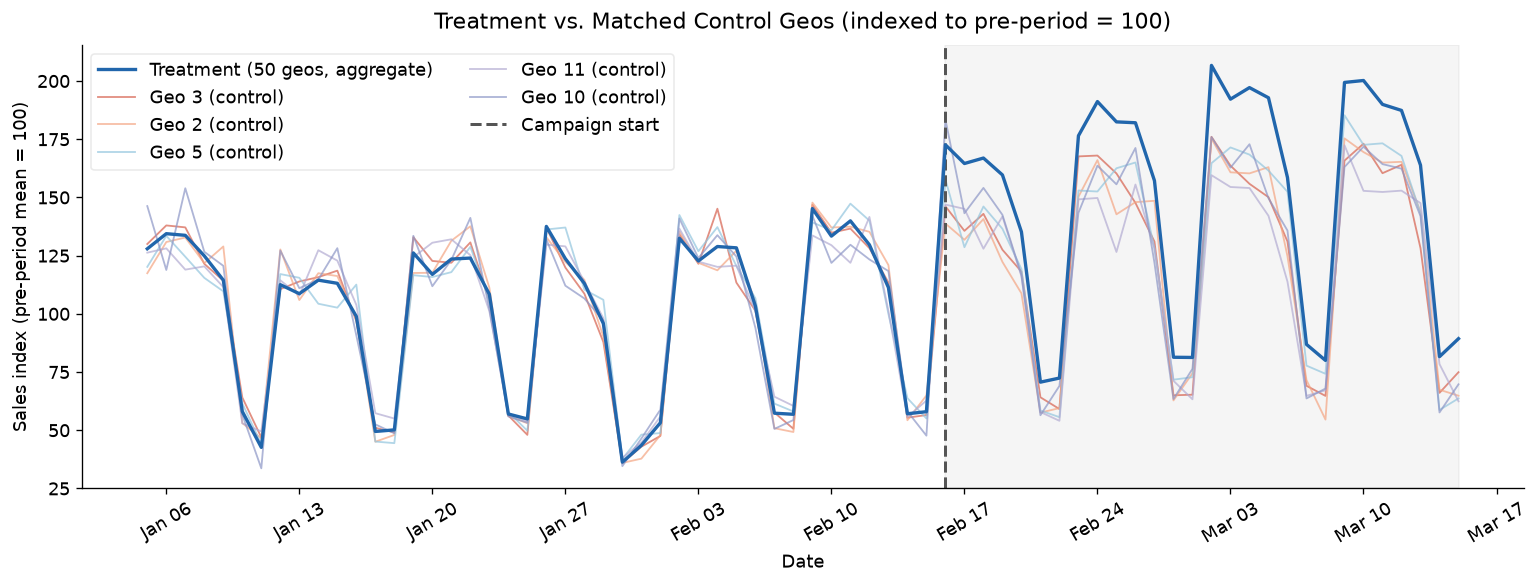

In [5]:
# Index all series to pre-period mean = 100 so treatment aggregate and single geos share a scale
fig, ax = plt.subplots(figsize=(13, 5))

def indexed(s):
    return s / s.loc[~post_mask].mean() * 100

ax.plot(df.index, indexed(df['treatment']), color=TREATMENT_COLOR, lw=2,
        label='Treatment (50 geos, aggregate)', zorder=3)

ctrl_colors = ['#D6604D', '#F4A582', '#92C5DE', '#B2ABD2', '#8C96C6']
for i, geo in enumerate(MATCHED_CONTROLS):
    ax.plot(df.index, indexed(df[geo]), color=ctrl_colors[i], lw=1.1,
            alpha=0.7, label=f'Geo {geo} (control)', zorder=2)

ax.axvline(campaign_start, color=VLINE_COLOR, ls='--', lw=1.8, label='Campaign start')
ax.axvspan(campaign_start, df.index[-1], alpha=0.06, color=VLINE_COLOR)
ax.set_title('Treatment vs. Matched Control Geos (indexed to pre-period = 100)', fontsize=13, pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Sales index (pre-period mean = 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
ax.legend(framealpha=0.4, ncol=2)
plt.tight_layout()
plt.savefig('../data/fig1_market_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**Figure 1.** Treatment and matched control geos track each other closely before the campaign start (dashed line). During the shaded campaign window the treatment series pulls above the controls — that divergence is what Phase 3 quantifies.

---
# Phase 3: CausalImpact Analysis

## How CausalImpact Works (Plain English)

CausalImpact is a Bayesian structural time-series model developed at Google:

1. **Learning phase (pre-period):** the model learns how the treatment series co-moves with the control geos — "when these controls move by X, treatment tends to move by Y."
2. **Prediction phase (post-period):** using that learned relationship and the controls' actual post-period values, it forecasts what the treatment series would have been *without* the campaign.
3. **Measurement:** the gap between observed sales and that counterfactual is the estimated causal effect.

Because the model is Bayesian, every estimate comes with a **credible interval**. If the interval excludes zero, the data is inconsistent with "no effect".

In [6]:
from causalimpact import CausalImpact

# tfcausalimpact fits by stochastic variational inference — seed TF/NumPy so results are reproducible
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

ci_data = df[['treatment'] + MATCHED_CONTROLS].copy()
ci_data.columns = ['y'] + [f'x{i+1}' for i in range(N_CONTROLS)]

ci = CausalImpact(ci_data, PRE_PERIOD, POST_PERIOD)
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    35509.87           994276.31
Prediction (s.d.)         29053.68 (1322.72) 813503.0 (37036.23)
95% CI                    [26453.72, 31638.69][740704.07, 885883.44]

Absolute effect (s.d.)    6456.19 (1322.72)  180773.31 (37036.23)
95% CI                    [3871.17, 9056.15] [108392.88, 253572.25]

Relative effect (s.d.)    22.22% (4.55%)     22.22% (4.55%)
95% CI                    [13.32%, 31.17%]   [13.32%, 31.17%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [7]:
sd = ci.summary_data

avg_actual    = float(sd.loc['actual',       'average'])
avg_predicted = float(sd.loc['predicted',    'average'])
abs_effect    = float(sd.loc['abs_effect',   'average'])
rel_effect    = float(sd.loc['rel_effect',   'average'])
rel_lo        = float(sd.loc['rel_effect_lower', 'average'])
rel_hi        = float(sd.loc['rel_effect_upper', 'average'])
cum_abs       = float(sd.loc['abs_effect',   'cumulative'])
cum_lo        = float(sd.loc['abs_effect_lower', 'cumulative'])
cum_hi        = float(sd.loc['abs_effect_upper', 'cumulative'])

roas    = cum_abs / CAMPAIGN_SPEND
roas_lo = cum_lo / CAMPAIGN_SPEND
roas_hi = cum_hi / CAMPAIGN_SPEND

print(f'Average daily actual sales    : ${avg_actual:,.0f}')
print(f'Average daily counterfactual  : ${avg_predicted:,.0f}')
print(f'Average daily lift            : ${abs_effect:,.0f}')
print(f'Relative lift                 : {rel_effect:.1%}  (95% CI: {rel_lo:.1%} – {rel_hi:.1%})')
print(f'Cumulative incremental sales  : ${cum_abs:,.0f}  (95% CI: ${cum_lo:,.0f} – ${cum_hi:,.0f})')
print(f'Campaign spend (actual)       : ${CAMPAIGN_SPEND:,.0f}')
print(f'Incremental ROAS              : {roas:.2f}x  (95% CI: {roas_lo:.2f}x – {roas_hi:.2f}x)')

Average daily actual sales    : $35,510
Average daily counterfactual  : $29,054
Average daily lift            : $6,456
Relative lift                 : 22.2%  (95% CI: 13.3% – 31.2%)
Cumulative incremental sales  : $180,773  (95% CI: $108,393 – $253,572)
Campaign spend (actual)       : $50,000
Incremental ROAS              : 3.62x  (95% CI: 2.17x – 5.07x)


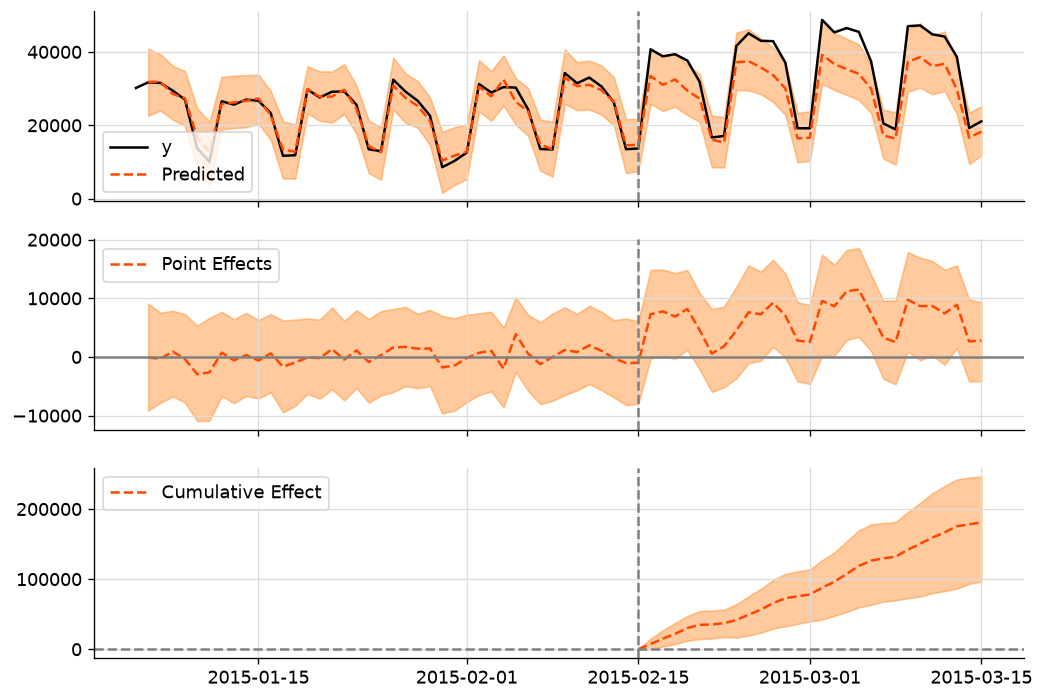

<Figure size 768x576 with 0 Axes>

In [8]:
ci.plot()
plt.suptitle('CausalImpact Analysis — Geo Campaign, Feb 16 – Mar 15 2015', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../data/fig2_causal_impact.png', dpi=120, bbox_inches='tight')
plt.show()

**Figure 2.** Three panels: (top) observed sales vs. counterfactual forecast; (middle) pointwise daily effect; (bottom) cumulative lift. The shaded band is the 95% credible interval — it sits above zero throughout the campaign window.

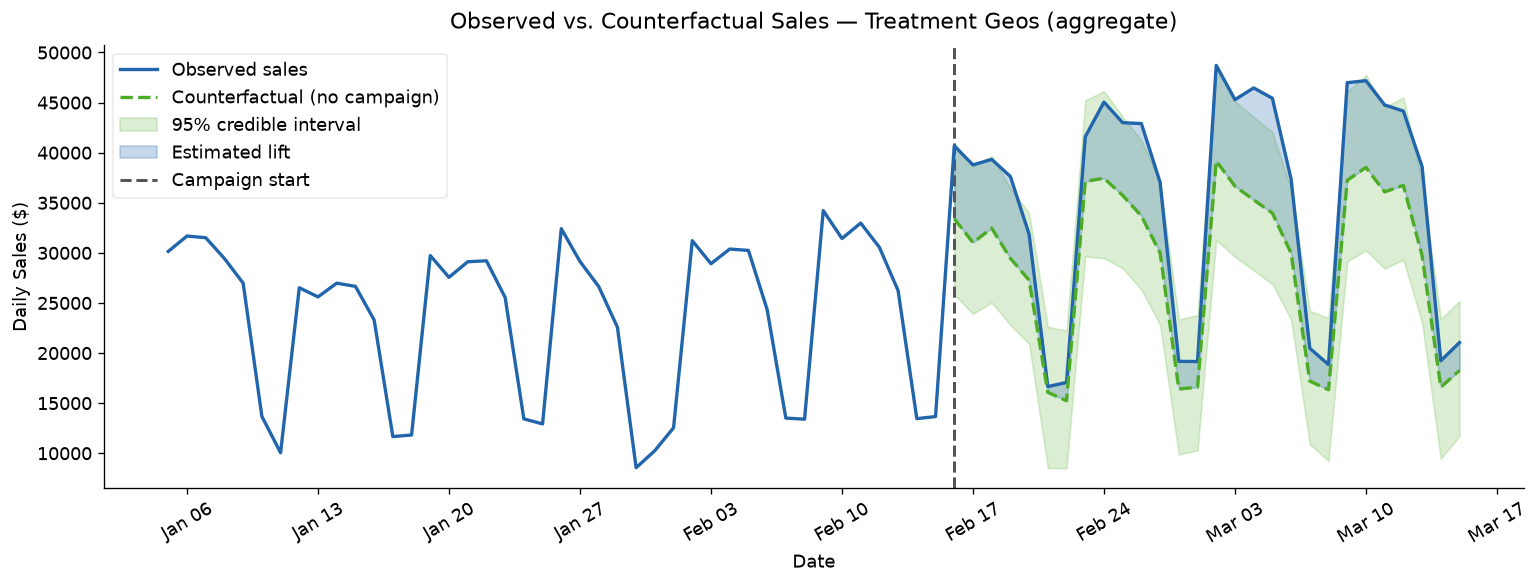

In [9]:
inferences = ci.inferences
post_inf   = inferences.loc[inferences.index >= campaign_start]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['treatment'], color=TREATMENT_COLOR, lw=2, label='Observed sales', zorder=3)
ax.plot(post_inf.index, post_inf['complete_preds_means'], color=COUNTER_COLOR,
        lw=2, ls='--', label='Counterfactual (no campaign)', zorder=3)
ax.fill_between(post_inf.index,
                post_inf['complete_preds_lower'], post_inf['complete_preds_upper'],
                alpha=0.2, color=COUNTER_COLOR, label='95% credible interval')
ax.fill_between(post_inf.index,
                post_inf['complete_preds_means'],
                df.loc[post_inf.index, 'treatment'],
                alpha=0.25, color=TREATMENT_COLOR, label='Estimated lift')
ax.axvline(campaign_start, color=VLINE_COLOR, ls='--', lw=1.8, label='Campaign start')

ax.set_title('Observed vs. Counterfactual Sales — Treatment Geos (aggregate)', fontsize=13, pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
ax.legend(framealpha=0.4)
plt.tight_layout()
plt.savefig('../data/fig3_obs_vs_counter.png', dpi=120, bbox_inches='tight')
plt.show()

**Figure 3.** The blue solid line is observed treatment-geo sales; the green dashed line is the counterfactual. The blue shading between them is the estimated incremental lift. The observed line sits consistently above the counterfactual band during the campaign window.

---
# Phase 4: Validating the Method

A skeptical stakeholder should ask: *how do we know this method gives the right answer?* Two tests:

1. **Recovery test (simulation):** generate data where the true lift is *known by construction*, run the identical pipeline, and check that the estimate recovers the truth. Only simulation can provide ground truth, which is why this test uses synthetic data.
2. **Placebo (A/A) test on real data:** apply the pipeline to a "fake treatment" group built from real *control* geos that received no spend. A trustworthy method should find no effect.

In [10]:
def run_causal_impact(df_in, treatment_col, control_cols, pre_per, post_per):
    """Fit CausalImpact and return (rel_effect, lower, upper, cum_abs, ci_object)."""
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    ci_df = df_in[[treatment_col] + list(control_cols)].copy()
    ci_df.columns = ['y'] + [f'x{i+1}' for i in range(len(control_cols))]
    ci_obj = CausalImpact(ci_df, pre_per, post_per)
    s = ci_obj.summary_data
    return (
        float(s.loc['rel_effect',       'average']),
        float(s.loc['rel_effect_lower', 'average']),
        float(s.loc['rel_effect_upper', 'average']),
        float(s.loc['abs_effect',       'cumulative']),
        ci_obj
    )

def make_market(baseline, noise_sd, seasonal_amp, seasonal_phase, n, rng, common=None):
    """Simulated daily sales: trend + weekly seasonality + shared demand shock + noise."""
    t = np.arange(n)
    trend  = baseline + 0.3 * t
    season = seasonal_amp * np.sin(2 * np.pi * t / 7 + seasonal_phase)
    shock  = (baseline / 500) * common if common is not None else 0
    noise  = rng.normal(0, noise_sd, n)
    return np.maximum(trend + season + shock + noise, 0)

print('Helpers defined.')

Helpers defined.


### Test 1: Recovery Test — Does the Model Find the Right Answer?

Five independent simulations with known true lifts of 5%, 10%, 15%, 20%, and 30%. Each simulation mimics the real data's structure — trend, weekly seasonality, a *common demand shock* shared across markets (so cross-market correlation isn't purely deterministic), and idiosyncratic noise. The lift is injected into the treatment series during the post-period, and the pipeline must recover it.

In [11]:
RNG = np.random.default_rng(99)
n_sim = len(df)
sim_dates = df.index
sim_pre  = [sim_dates[0], campaign_start - pd.Timedelta(days=1)]
sim_post = [campaign_start, sim_dates[-1]]

true_lifts    = [0.05, 0.10, 0.15, 0.20, 0.30]
recovery_rows = []

for true_lift in true_lifts:
    # Shared demand shock: stationary AR(1), common to all markets in this simulation
    innov = RNG.normal(0, 12, n_sim)
    common = np.zeros(n_sim)
    for t in range(1, n_sim):
        common[t] = 0.8 * common[t - 1] + innov[t]
    sim = pd.DataFrame({
        'T':  make_market(500, 25, 40, 0.00, n_sim, RNG, common),
        'C1': make_market(485, 22, 38, 0.10, n_sim, RNG, common),
        'C2': make_market(508, 28, 41, 0.05, n_sim, RNG, common),
        'C3': make_market(492, 24, 39, 0.08, n_sim, RNG, common),
    }, index=sim_dates)
    sim.loc[sim.index >= campaign_start, 'T'] *= (1 + true_lift)

    rel, lo, hi, _, _ = run_causal_impact(sim, 'T', ['C1', 'C2', 'C3'], sim_pre, sim_post)
    recovery_rows.append({'True Lift': f'{true_lift:.0%}', 'Estimated Lift': f'{rel:.1%}',
                          '95% CI Lower': f'{lo:.1%}', '95% CI Upper': f'{hi:.1%}',
                          'True in CI?': 'yes' if lo <= true_lift <= hi else 'NO',
                          '_rel': rel, '_lo': lo, '_hi': hi, '_true': true_lift})

recovery_df = pd.DataFrame(recovery_rows)
print(recovery_df[['True Lift','Estimated Lift','95% CI Lower','95% CI Upper','True in CI?']].to_string(index=False))

True Lift Estimated Lift 95% CI Lower 95% CI Upper True in CI?
       5%           6.1%         3.2%         9.0%         yes
      10%          12.0%         8.7%        15.2%         yes
      15%          18.9%        14.5%        22.9%         yes
      20%          23.0%        19.9%        26.3%         yes
      30%          29.8%        26.9%        32.7%         yes


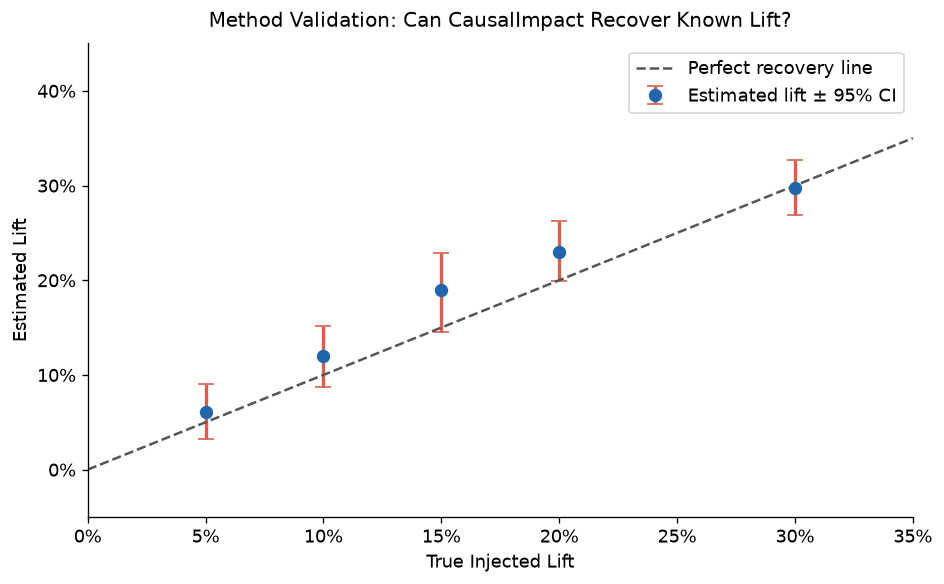

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

true_v = [r['_true'] for r in recovery_rows]
est_v  = [r['_rel']  for r in recovery_rows]
lo_v   = [r['_lo']   for r in recovery_rows]
hi_v   = [r['_hi']   for r in recovery_rows]
yerr   = [np.array(est_v) - np.array(lo_v), np.array(hi_v) - np.array(est_v)]

ax.errorbar(true_v, est_v, yerr=yerr, fmt='o', color=TREATMENT_COLOR,
            ecolor=CONTROL_COLOR, elinewidth=2, capsize=5, ms=7,
            label='Estimated lift ± 95% CI')
ax.plot([0, 0.35], [0, 0.35], '--', color=VLINE_COLOR, lw=1.5, label='Perfect recovery line')
ax.set_xlim(0, 0.35)
ax.set_ylim(-0.05, 0.45)
ax.set_xlabel('True Injected Lift')
ax.set_ylabel('Estimated Lift')
ax.set_title('Method Validation: Can CausalImpact Recover Known Lift?', fontsize=12, pad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.savefig('../data/fig4_recovery_test.png', dpi=120, bbox_inches='tight')
plt.show()

**Figure 4.** Each point is one simulation: true lift on the x-axis, estimated lift on the y-axis, error bars are 95% credible intervals. Estimates track the 45° perfect-recovery line; the table above reports whether the true value fell inside each interval. With one run per lift level, an occasional near-miss is expected — a 95% interval misses 1 time in 20 by design.

### Test 2: Placebo (A/A) Test on Real Data — Does the Model Stay Silent When Nothing Happened?

We build a fake "treatment" group from real control geos that received zero spend, and use other, disjoint control geos as covariates. Since no campaign touched any of these geos, the pipeline should report a credible interval that includes zero. Running the placebo on *real* data (rather than simulation) tests the method against the dataset's actual noise structure.

One design detail matters: the fake-treatment group and the covariate pool should have similar composition. We rank control geos by correlation with the real treatment series and *interleave* them — alternating geos into the fake group and the covariate pool — so neither side is systematically larger or better-matched than the other. (An earlier draft that put the top-ranked geos in the fake group and the leftovers in the pool produced a spurious "significant" placebo effect — an instructive failure: a placebo test is only as valid as the comparability of its two sides.)

In [13]:
# Interleave correlation-ranked control geos into a fake-treatment group and a covariate pool
ranked = corr_df['geo'].tolist()
fake_treated = ranked[0::2]            # 25 untreated geos → fake "treatment" aggregate
placebo_pool = ranked[1::2]            # 25 untreated geos → candidate covariates

df_placebo = df.copy()
df_placebo['fake_treatment'] = df_placebo[fake_treated].sum(axis=1)

pre_placebo = df_placebo.loc[~post_mask]
placebo_corr = sorted(placebo_pool,
                      key=lambda g: -pearsonr(pre_placebo['fake_treatment'], pre_placebo[g])[0])
placebo_controls = placebo_corr[:N_CONTROLS]

rel_aa, lo_aa, hi_aa, _, ci_aa = run_causal_impact(
    df_placebo, 'fake_treatment', placebo_controls, PRE_PERIOD, POST_PERIOD
)

print('Placebo (A/A) Test on Real Control Geos')
print(f'  Estimated lift : {rel_aa:.2%}')
print(f'  95% CI         : {lo_aa:.2%} – {hi_aa:.2%}')
print(f'  Zero in CI?    : {lo_aa <= 0 <= hi_aa}  (should be True)')

Placebo (A/A) Test on Real Control Geos
  Estimated lift : 4.83%
  95% CI         : -4.27% – 14.42%
  Zero in CI?    : True  (should be True)


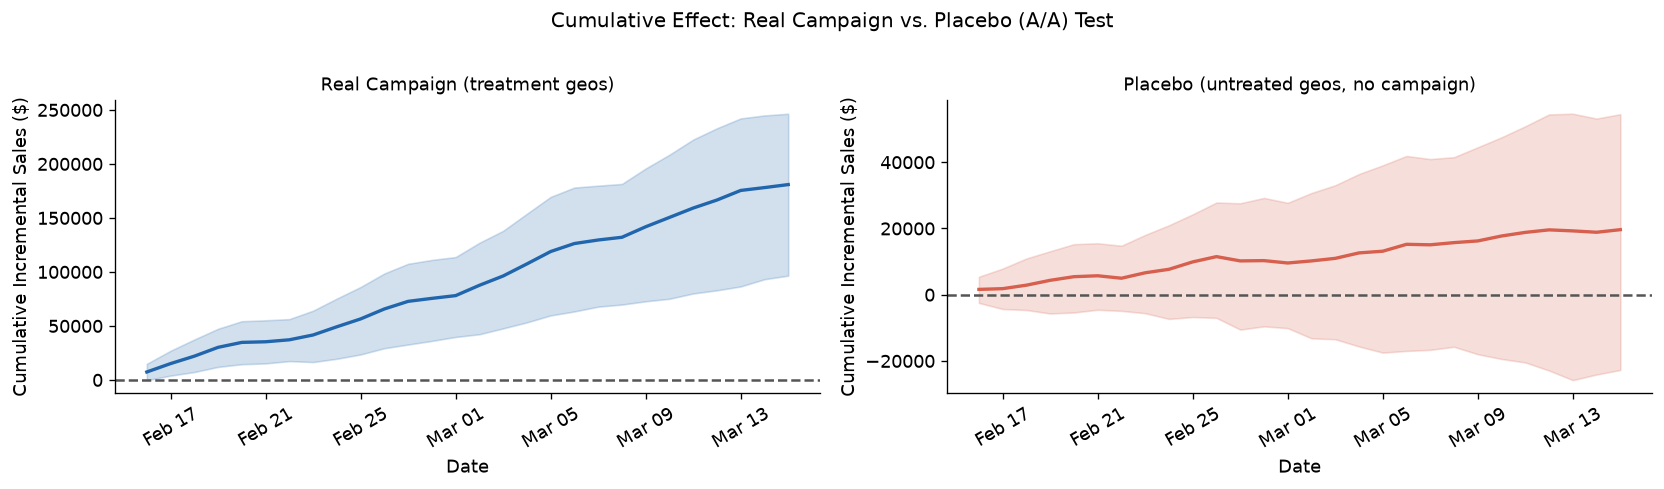

In [14]:
inf_real = ci.inferences
inf_aa   = ci_aa.inferences

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax_i, (inf, title, color) in enumerate([
    (inf_real, 'Real Campaign (treatment geos)',        TREATMENT_COLOR),
    (inf_aa,   'Placebo (untreated geos, no campaign)', CONTROL_COLOR),
]):
    post_slice = inf.loc[inf.index >= campaign_start].dropna(subset=['post_cum_effects_means'])
    axes[ax_i].plot(post_slice.index, post_slice['post_cum_effects_means'], color=color, lw=2)
    axes[ax_i].fill_between(post_slice.index,
                             post_slice['post_cum_effects_lower'],
                             post_slice['post_cum_effects_upper'],
                             alpha=0.2, color=color)
    axes[ax_i].axhline(0, color=VLINE_COLOR, ls='--', lw=1.5)
    axes[ax_i].set_title(title, fontsize=11)
    axes[ax_i].set_xlabel('Date')
    axes[ax_i].set_ylabel('Cumulative Incremental Sales ($)')
    axes[ax_i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(axes[ax_i].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Cumulative Effect: Real Campaign vs. Placebo (A/A) Test', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../data/fig5_placebo_test.png', dpi=120, bbox_inches='tight')
plt.show()

**Figure 5.** Left: cumulative lift for the real campaign — the credible band is above zero throughout. Right: the placebo run on untreated geos — the band straddles zero, correctly finding no effect.

### Validation Summary

Across five simulations with ground-truth lifts from 5% to 30%, the estimated lift tracked the true value closely (see the table for per-run interval coverage). The placebo test on real, untreated geos returned a null result. Both failure modes — missing real effects and inventing fake ones — were checked.

---
# Phase 5: Recommendation & Caveats

## Business Recommendation

*(Numbers below are computed in Phase 3 from the real campaign data.)*

The campaign produced a statistically credible lift in treatment-geo sales during the four-week spend window, with a 95% credible interval clearly above zero. Whether to scale depends on the incremental ROAS against the margin structure of the business: at the estimated ROAS, the campaign is worth scaling if incremental gross margin per revenue dollar exceeds 1/ROAS. The natural next step is a second wave in additional geos with a pre-registered analysis plan — pre-period, post-period, control-selection rule, and decision threshold fixed before the data comes in.

## Caveats

**Spillover between adjacent markets.** If treated and control geos are geographically close, campaign exposure can leak across boundaries and compress the measured lift. The public dataset anonymizes geo identity, so adjacency can't be checked here; in a live test, market selection should enforce geographic separation.

**Match quality determines everything.** The counterfactual is only as good as the pre-period relationship between treatment and controls. Any structural break affecting only the treatment geos during the pre-period would corrupt the match. The pre-period fit should always be inspected (Figure 2, top panel, left of the dashed line).

**Pre-period length.** Six weeks of pre-period captures weekly cycles but not annual seasonality. For seasonal businesses the pre-period should span at least one full seasonal cycle.

**External shocks during the post-period.** A weather event, competitor promotion, or local economic shock hitting treatment geos only would be indistinguishable from campaign effect. Randomized geo assignment (as in this experiment's design) makes such confounds unlikely but not impossible.

## Connection to Broader Measurement

Geo incrementality tests answer a campaign-level ROI question, and they also produce ground-truth lift estimates that can calibrate a Marketing Mix Model (MMM). An MMM fitted on observational data alone struggles to separate baseline demand from paid-media effects; periodic geo experiments provide the anchor points that pin down channel-level contributions and make budget-allocation decisions more reliable.